In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

from studio_preprocessing_tools import *

In [2]:
blat_wt = "MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRVDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPAAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW"
blat_eco_data = pd.read_csv("blat_eco.csv", header=3).set_index("mutant")
blat_eco_data

,effect_prediction_epistatic,effect_prediction_independent,0,39,156,625,2500,cefotaxime
mutant,,,,,,,,
H24A,NaN,NaN,0.014913,-0.002285,-0.010777,0.003888,-0.009784,-0.028149
H24C,NaN,NaN,0.022702,0.045890,-0.025738,0.018871,-0.418260,-0.031941
H24E,NaN,NaN,0.011387,-0.012636,-0.018955,-0.020436,-0.279024,0.016456
H24D,NaN,NaN,0.042301,0.017005,0.018951,0.006743,-0.181607,-0.030326
H24G,NaN,NaN,0.011460,-0.024511,-0.023807,-0.017209,-0.060242,-0.009657
...,...,...,...,...,...,...,...,...
W286S,NaN,NaN,-0.035006,-0.110907,-1.368384,-2.347502,-2.967712,0.049699
W286R,NaN,NaN,-0.025877,-0.012935,-0.853984,-1.902061,-2.707731,0.021912
W286T,NaN,NaN,-0.072449,-0.120705,-1.316637,-2.070245,-2.806422,0.046944


In [3]:
df = blat_eco_data[["0", "39", "156", "625", "2500", "cefotaxime"]]
df.loc['M1M'] = np.zeros(6)
df = assign_mutant_column(df)

/tmp/ipykernel_1334705/782513944.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc['M1M'] = np.zeros(6)
/n/groups/marks/users/sam/SpecificityStudio/notebooks/Assay processing notebooks/studio_preprocessing_tools.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mutant'] = pd.Series(mutants, index=df.index)


(array([  0.,   0.,   1.,   0.,   6.,  10.,  39.,  48.,  82., 118., 150.,
        164., 183., 142., 146., 130., 120., 104.,  98.,  86., 114., 110.,
        140., 131., 139.,  85.,  72.,  61.,  59.,  47.,  60.,  51.,  49.,
         81.,  67.,  66., 113., 186., 331., 910., 461.,  34.,   2.,   2.]),
 array([-4.00000000e+00, -3.90000000e+00, -3.80000000e+00, -3.70000000e+00,
        -3.60000000e+00, -3.50000000e+00, -3.40000000e+00, -3.30000000e+00,
        -3.20000000e+00, -3.10000000e+00, -3.00000000e+00, -2.90000000e+00,
        -2.80000000e+00, -2.70000000e+00, -2.60000000e+00, -2.50000000e+00,
        -2.40000000e+00, -2.30000000e+00, -2.20000000e+00, -2.10000000e+00,
        -2.00000000e+00, -1.90000000e+00, -1.80000000e+00, -1.70000000e+00,
        -1.60000000e+00, -1.50000000e+00, -1.40000000e+00, -1.30000000e+00,
        -1.20000000e+00, -1.10000000e+00, -1.00000000e+00, -9.00000000e-01,
        -8.00000000e-01, -7.00000000e-01, -6.00000000e-01, -5.00000000e-01,
        -4.0000000

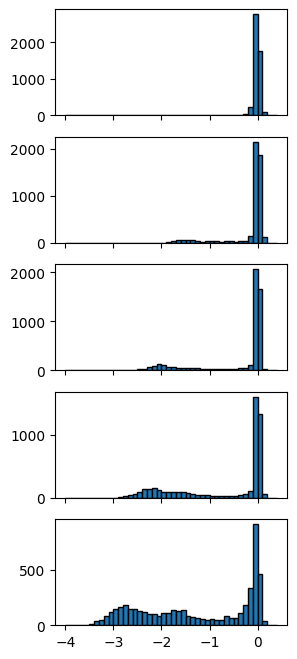

In [7]:
fig, ax = plt.subplots(5,1, figsize=(3,8), sharex=True)
ax[0].hist(df["0"], ec='k', bins=np.arange(-4,0.5, 0.1))
ax[1].hist(df["39"], ec='k', bins=np.arange(-4,0.5, 0.1))
ax[2].hist(df["156"], ec='k', bins=np.arange(-4,0.5, 0.1))
ax[3].hist(df["625"], ec='k', bins=np.arange(-4,0.5, 0.1))
ax[4].hist(df["2500"], ec='k', bins=np.arange(-4,0.5, 0.1))

In [8]:
df = blat_eco_data[["0", "39", "156", "625", "2500", "cefotaxime"]]
df.loc['M1M'] = np.zeros(6)
df = assign_mutant_column(df)
df.loc[:, 'mutated_sequence'] = [apply_mutations(blat_wt, muts) for muts in df.index]
df['DMS_score'] = df['2500']

df = assign_specificity_categories(df, 
                              lambda var,row: row['2500']<-1 and row.cefotaxime<0.2,
                              lambda var,row: row.cefotaxime>0.2)

/tmp/ipykernel_3879594/197608225.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc['M1M'] = np.zeros(6)
/n/groups/marks/users/sam/SpecificityStudio/notebooks/Assay processing notebooks/studio_preprocessing_tools.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mutant'] = pd.Series(mutants, index=df.index)
/tmp/ipykernel_3879594/197608225.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

In [10]:
df.loc['wt'] = df.loc['M1M'].copy()

In [14]:
df.drop('wt')

,0,39,156,625,2500,cefotaxime,mutant,mutated_sequence,DMS_score,specificity_category
mutant,,,,,,,,,,
H24A,0.014913,-0.002285,-0.010777,0.003888,-0.009784,-0.028149,H24A,MSIQHFRVALIPFFAAFCLPVFAAPETLVKVKDAEDQLGARVGYIE...,-0.009784,native-specificity
H24C,0.022702,0.045890,-0.025738,0.018871,-0.418260,-0.031941,H24C,MSIQHFRVALIPFFAAFCLPVFACPETLVKVKDAEDQLGARVGYIE...,-0.418260,native-specificity
H24E,0.011387,-0.012636,-0.018955,-0.020436,-0.279024,0.016456,H24E,MSIQHFRVALIPFFAAFCLPVFAEPETLVKVKDAEDQLGARVGYIE...,-0.279024,native-specificity
H24D,0.042301,0.017005,0.018951,0.006743,-0.181607,-0.030326,H24D,MSIQHFRVALIPFFAAFCLPVFADPETLVKVKDAEDQLGARVGYIE...,-0.181607,native-specificity
H24G,0.011460,-0.024511,-0.023807,-0.017209,-0.060242,-0.009657,H24G,MSIQHFRVALIPFFAAFCLPVFAGPETLVKVKDAEDQLGARVGYIE...,-0.060242,native-specificity
...,...,...,...,...,...,...,...,...,...,...
W286R,-0.025877,-0.012935,-0.853984,-1.902061,-2.707731,0.021912,W286R,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,-2.707731,inactive
W286T,-0.072449,-0.120705,-1.316637,-2.070245,-2.806422,0.046944,W286T,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,-2.806422,inactive
W286V,-0.015917,-0.036848,-0.943011,-1.866516,-2.813837,0.027214,W286V,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,-2.813837,inactive


In [15]:
check_dataset(df)
df.drop('wt').to_csv("../../processed_data/BLAT_ECOLX_Stiffler_2015.csv")

Checking dataset table:
✅ DMS_score in table
✅ mutated_sequence in table
✅ mutant in table
✅ Contains WT sequence (M1M)
✅ all mutants pass checks and match sequence

✅ All checks passed!


<Axes: xlabel='2500', ylabel='cefotaxime'>

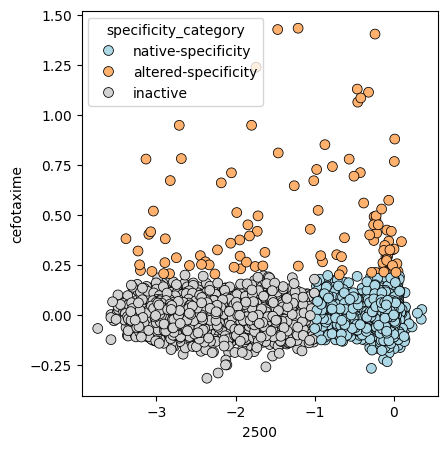

In [7]:
plt.figure(figsize=(4.6,5))
sns.scatterplot(data=df, x="2500", y="cefotaxime", ec='k', s=50, hue="specificity_category",
               palette={"native-specificity":"lightblue", "altered-specificity":"xkcd:apricot", "inactive":"lightgray"})

In [8]:
df.loc[df.cefotaxime>0.2].index

Index(['H24P', 'M67C', 'K71C', 'V72E', 'I93C', 'E102I', 'E102K', 'E102M',
       'E102R', 'Y103W',
       ...
       'R238P', 'G239H', 'G239N', 'G239S', 'G239T', 'S240D', 'S240G', 'G263P',
       'G263V', 'S264R'],
      dtype='object', name='mutant', length=106)

In [1]:
def get_specificity_positions(df):
    sp_muts = selector(df, {'specificity_category': 'altered-specificity'}).mutant
    return pd.Series([i[1:-1] for i in sp_muts]).value_counts()

sp_pos = get_specificity_positions(df)
print('+'.join(sp_pos.index))

for pos,n in sp_pos.items():
    print(f"set sphere_scale, {n/8}, bla_specificity and res {pos};")

NameError: name 'df' is not defined

In [5]:
np.savetxt('../../processed_data/blat_ESCOTT.mut', df.mutant.values, fmt="%s")
np.savetxt('../../processed_data/blat_GEMME.mut', [i.replace(':',',') for i in df.mutant.values], fmt="%s")

In [6]:
df

,0,39,156,625,2500,cefotaxime,mutant
mutant,,,,,,,
H24A,0.014913,-0.002285,-0.010777,0.003888,-0.009784,-0.028149,H24A
H24C,0.022702,0.045890,-0.025738,0.018871,-0.418260,-0.031941,H24C
H24E,0.011387,-0.012636,-0.018955,-0.020436,-0.279024,0.016456,H24E
H24D,0.042301,0.017005,0.018951,0.006743,-0.181607,-0.030326,H24D
H24G,0.011460,-0.024511,-0.023807,-0.017209,-0.060242,-0.009657,H24G
...,...,...,...,...,...,...,...
W286R,-0.025877,-0.012935,-0.853984,-1.902061,-2.707731,0.021912,W286R
W286T,-0.072449,-0.120705,-1.316637,-2.070245,-2.806422,0.046944,W286T
W286V,-0.015917,-0.036848,-0.943011,-1.866516,-2.813837,0.027214,W286V
